# k-Nearest Neighbour Classification #

#### Imports ####

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import os
import seaborn as sns
import matplotlib.pyplot as plt

#### Load Cleaned Dataset ####

In [5]:
script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

#### Feature Selection ####

Essential features include cushion volume (ACPx), injection time (ZSx), two temperature measures (H16x and H10x).

Additionally chosen features include dosing time (ZDx), energy consumption (GEx) and cycle time (ZUs). However these might show multicollinearity, so they need to be monitored

In [10]:
features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZUs [s]', 'ZEx [s]', 'GEx [kWh]', 'H16x [°C]', 'H10x [°C]']

X = dataset[features]
y = dataset['ASZ [Sch]']

#### Splitting and Scaling Data ####

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Train kNN ####

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Evaluate Model ####

In [14]:
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       933
           1       0.90      0.97      0.94        38

    accuracy                           0.99       971
   macro avg       0.95      0.98      0.97       971
weighted avg       1.00      0.99      0.99       971



#### Plot Confusion Matrix ####

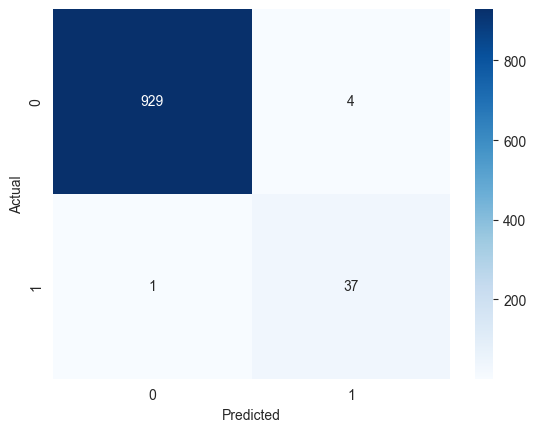

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

True Negatives = 929
True Positives = 37
False Negatives = 1
False Positives = 4

#### Double-checking if one feature is carrying the entire model ####
We shuffle one column at a time and see if the model's performance drops.

In [18]:
results = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)

for i in results.importances_mean.argsort()[::-1]:
    print(f"{features[i]}: {results.importances_mean[i]:.3f}")

ZUs [s]: 0.069
ZSx [s]: 0.001
ZEx [s]: 0.000
GEx [kWh]: 0.000
H16x [°C]: -0.000
ZDx [s]: -0.000
H10x [°C]: -0.001
ACPx [cm³]: -0.001


We see that demolding time dominates the model, to the point where the other features play no role. Hence, we remove ZUs and rerun.

In [19]:
features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'GEx [kWh]', 'H16x [°C]', 'H10x [°C]']

X2 = dataset[features]

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X2, y, test_size=0.2, random_state=42)
scaler_2 = StandardScaler()
X_train_2 = scaler_2.fit_transform(X_train_2)
X_test_2 = scaler_2.transform(X_test_2)

knn_2 = KNeighborsClassifier(n_neighbors=5)
knn_2.fit(X_train_2, y_train_2)
y_pred_2 = knn_2.predict(X_test_2)

print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       933
           1       0.91      0.53      0.67        38

    accuracy                           0.98       971
   macro avg       0.95      0.76      0.83       971
weighted avg       0.98      0.98      0.98       971



By removing cycle time, our recall for scrap dropped from 97% to 53%. This means that defective parts are indistinguishable from good ones uing only the remaining sensors.

We try rerunning but now making the model look for only 3 neighbours instead of 5.

In [21]:
features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'GEx [kWh]', 'H16x [°C]', 'H10x [°C]']

X2 = dataset[features]

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X2, y, test_size=0.2, random_state=42)
scaler_2 = StandardScaler()
X_train_2 = scaler_2.fit_transform(X_train_2)
X_test_2 = scaler_2.transform(X_test_2)

knn_2 = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_2.fit(X_train_2, y_train_2)
y_pred_2 = knn_2.predict(X_test_2)

print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       933
           1       0.79      0.50      0.61        38

    accuracy                           0.98       971
   macro avg       0.89      0.75      0.80       971
weighted avg       0.97      0.98      0.97       971



In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 1. Initialize SMOTE
# We only apply this to the TRAINING data to avoid data leakage
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_2, y_train_2)

print(f'Before SMOTE: {sum(y_train_2 == 1)} scrap samples')
print(f'After SMOTE: {sum(y_train_res == 1)} scrap samples')

# 2. Re-train the kNN on the balanced dataset
# I recommend setting weights='distance' so closer points have more influence
knn_smote = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_smote.fit(X_train_res, y_train_res)

# 3. Evaluate on the original (un-smoted) test set
y_pred_smote = knn_smote.predict(X_test_2)

print(classification_report(y_test_2, y_pred_smote))

Before SMOTE: 125 scrap samples
After SMOTE: 3758 scrap samples
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       933
           1       0.54      0.76      0.63        38

    accuracy                           0.96       971
   macro avg       0.76      0.87      0.81       971
weighted avg       0.97      0.96      0.97       971



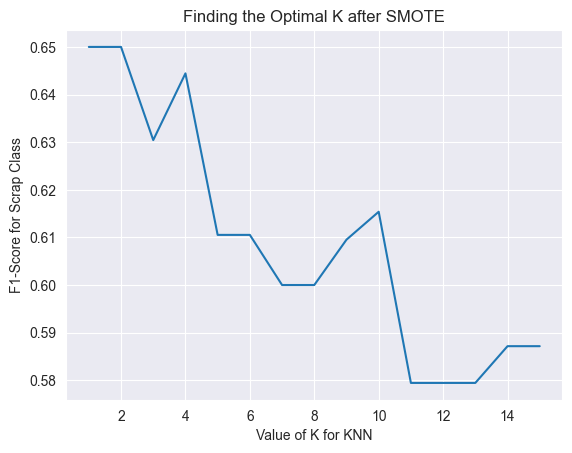

In [27]:
import matplotlib.pyplot as plt

# Test K from 1 to 15
k_range = range(1, 16)
scores = []

for k in k_range:
    knn_test = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_test.fit(X_train_res, y_train_res)
    # We focus on the F1-score for class 1 (scrap)
    report = classification_report(y_test_2, knn_test.predict(X_test_2), output_dict=True)
    scores.append(report['1']['f1-score'])

plt.plot(k_range, scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('F1-Score for Scrap Class')
plt.title('Finding the Optimal K after SMOTE')
plt.show()

In [40]:
g

X2 = dataset[features]

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X2, y, test_size=0.2, random_state=42)
scaler_2 = StandardScaler()
X_train_2 = scaler_2.fit_transform(X_train_2)
X_test_2 = scaler_2.transform(X_test_2)

knn_2 = KNeighborsClassifier(n_neighbors=2, weights='distance')
knn_2.fit(X_train_2, y_train_2)
y_pred_2 = knn_2.predict(X_test_2)

print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       933
           1       0.84      0.71      0.77        38

    accuracy                           0.98       971
   macro avg       0.92      0.85      0.88       971
weighted avg       0.98      0.98      0.98       971

